### Experiments and code related to Bayesian GP part of the algorithm

#### Issues

In [1]:
# Adjust import path
import sys
sys.path.append("../things")
sys.path.append("../")

import os
import h5py
import numpy as np

import opinf

import config
import utils
import step1_generate_data as step1

import matplotlib.pyplot as plt
from things.bgp_jax import BayesianGP
import jax.numpy as jnp
import jax

Logging to log.log


INFO:2025-06-20 13:55:50,245:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/anthonypoole/miniconda3/envs/prob_rom/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


#### Generate Noisy Data

In [2]:
training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [3]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.40 s.


#### Do a deterministic fit

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.05 s.
Weight matrix None
Off diagonal loss 3.284699e-15


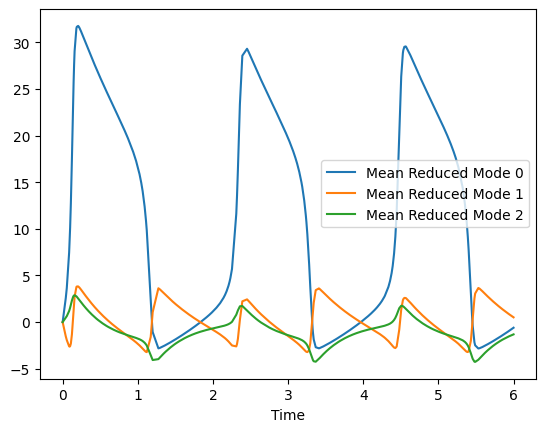

In [4]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

V = basis.entries
W = basis.weights
print(f'Weight matrix', W)

off_diagonal_loss = jnp.sum((V.T @ V) - jnp.eye(V.shape[1])**2)
print("Off diagonal loss", off_diagonal_loss)

for i in range(numPODmodes):
    plt.plot(time_domain_sampled, snapshots_compressed[i], label = f"Mean Reduced Mode {i}")
plt.xlabel('Time')
plt.legend()

#### Fit Bayesian GP to the compressed snapshots

In [5]:
gps = []
K_yys = []
for i in range(numPODmodes):
    # Initialize
    gp = BayesianGP(kernel='rbf', normalization=1e-4)
    # Fit with NUTS sampling
    gp.fit(time_domain_sampled[:,None], snapshots_compressed[i, :], num_samples=100, warmup_steps=50) # Takes shape (time, 1) and (time,)
    gps.append(gp)

sample: 100%|██████████| 150/150 [00:13<00:00, 10.73it/s, 31 steps of size 9.77e-04. acc. prob=0.12] 



MCMC completed with 100 samples

Posterior Summary:
----------------------------------------
lengthscale : mean=0.055, std=0.001
variance    : mean=119.450, std=5.416
noise       : mean=0.000, std=0.000


sample: 100%|██████████| 150/150 [00:03<00:00, 39.44it/s, 7 steps of size 3.45e-02. acc. prob=0.17]



MCMC completed with 100 samples

Posterior Summary:
----------------------------------------
lengthscale : mean=0.047, std=0.000
variance    : mean=2.069, std=0.125
noise       : mean=0.000, std=0.000


sample: 100%|██████████| 150/150 [00:04<00:00, 33.16it/s, 3 steps of size 1.68e-02. acc. prob=0.04]


MCMC completed with 100 samples

Posterior Summary:
----------------------------------------
lengthscale : mean=0.072, std=0.001
variance    : mean=1.710, std=0.028
noise       : mean=0.000, std=0.000


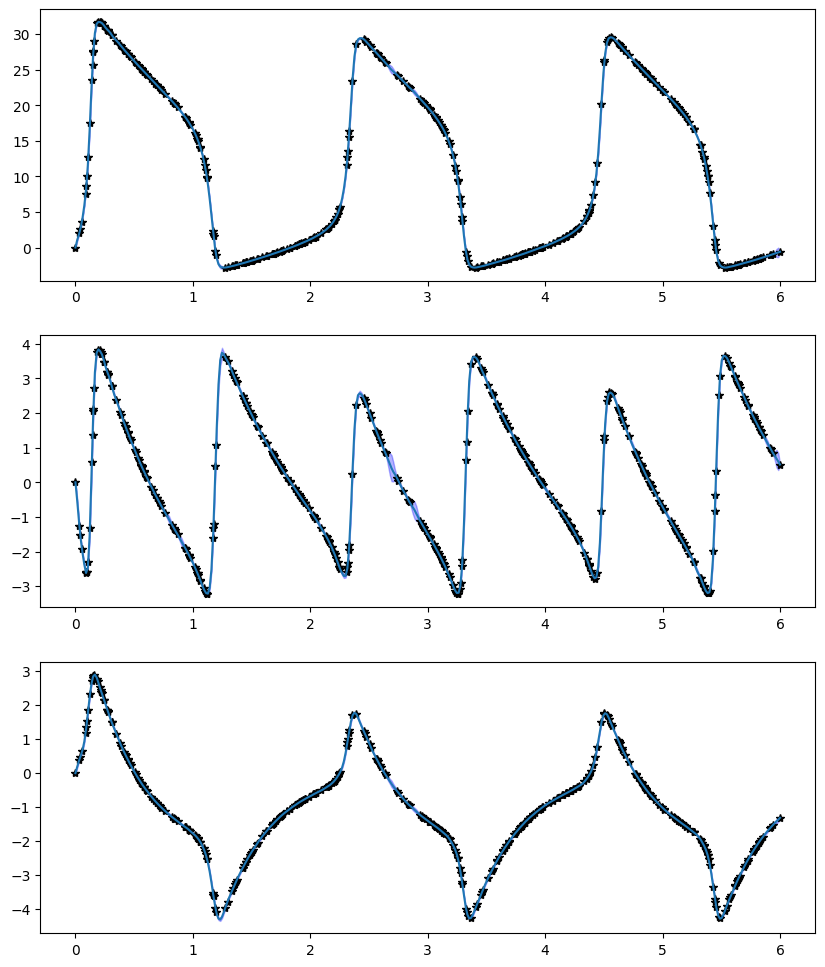

In [7]:
fig, ax = plt.subplots(3, 1,  figsize = (10,12))

X_test = jnp.linspace(0,6,400)
for i in range(numPODmodes):
    pred_mean_jax, pred_std_jax, pred_samples_jax = gps[i].predict(X_test[:,None], num_samples=50)
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')
    ax[i].plot(X_test, pred_mean_jax)
    ax[i].fill_between(X_test.squeeze(), 
                     (pred_mean_jax - 2*pred_std_jax),
                     (pred_mean_jax + 2*pred_std_jax),
                     alpha=0.3, color='blue', label='±2 sigma')